# XGBoost

In this notebook, we train XGBoost models to predict dry (0) or wet (1) for a given HJ Andrews HOBO Sensor Site 3 days after a given date. The model uses features at time t and the current wet/dry status (target[t]) to predict target[t+3]. We apply ADASYN to the training data.

We experiment with the following train-test-splitting strategies:
- Random
- Temporal
- Site-based

We evaluate by splitting strategy and stream order.

At the bottom of the notebook, we provide a function for practictioners to run inference with our trained models for an inputted site-date combination.

## Imports

In [1]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split
import numpy as np
np.random.seed(42)

## Data Preprocessing

In [2]:
# Data Paths
DRIVERS_PATH = "../data/sciencebase/met_drivers.csv"
OBS_PATH = "../data/sciencebase/obs.csv"
STATIC_PATH = "../data/sciencebase/static_vars.csv"
DEGREES_PATH = "../data/huggingface/degrees.parquet"
ORDER_PATH = "../data/huggingface/nhd_id_stream_order_permanence.csv"

# Load drivers dataset as CSV
drivers = pd.read_csv(DRIVERS_PATH)

# Loads obs data
obs_df = pd.read_csv(OBS_PATH)

# Load in remaining datasets
static_df = pd.read_csv(STATIC_PATH)
degrees = pd.read_parquet(DEGREES_PATH)
stream_order = pd.read_csv(ORDER_PATH)

obs_df

,NHDPlusID,SiteIDCode,Date,Discharge_CMS,MaxDepth_cm,MaxDepth_Threshold,MaxDepth_Censor,Flow_Status,HoboWetDry0.05
0,55000900130309,GSWS01,1980-01-01,0.045505,NaN,NaN,NaN,NaN,NaN
1,55000900130309,GSWS01,1980-01-02,0.043410,NaN,NaN,NaN,NaN,NaN
2,55000900130309,GSWS01,1980-01-03,0.048592,NaN,NaN,NaN,NaN,NaN
3,55000900130309,GSWS01,1980-01-04,0.061872,NaN,NaN,NaN,NaN,NaN
4,55000900130309,GSWS01,1980-01-05,0.276599,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
159074,55000900237668,HoboSite99,2020-10-25,NaN,NaN,NaN,NaN,NaN,0.0
159075,55000900237668,HoboSite99,2020-10-26,NaN,NaN,NaN,NaN,NaN,0.0
159076,55000900237668,HoboSite99,2020-10-27,NaN,NaN,NaN,NaN,NaN,0.0
159077,55000900130309,WDLookMcRaeID1,2020-07-08,NaN,48.768,0.0,1.0,NaN,NaN


In [3]:
# Extract HOBO wet/dry observations and MaxDepth obs (excluding Discharge)
OBS_EXTRA_COLS = ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']
# obs.csv is already in wide form (one column per observation type),
# so each row has at most one variable populated and the rest are NaN.
hobo_df = obs_df[obs_df['HoboWetDry0.05'].notna()][
    ['NHDPlusID', 'SiteIDCode', 'Date', 'HoboWetDry0.05']
].rename(columns={'HoboWetDry0.05': 'wetdry_status'})

# MaxDepth columns are already present in wide-form obs_df; keep only rows
# where at least one MaxDepth value is observed.
max_depth_wide = obs_df.loc[
    obs_df[OBS_EXTRA_COLS].notna().any(axis=1),
    ['NHDPlusID', 'Date'] + OBS_EXTRA_COLS,
]

In [4]:
# Normalize types before merging
hobo_df = hobo_df.copy()
hobo_df['NHDPlusID'] = hobo_df['NHDPlusID'].astype(str)
drivers['NHDPlusID'] = drivers['NHDPlusID'].astype(str)
static_df['NHDPlusID'] = static_df['NHDPlusID'].astype(str)
stream_order['NHDPlusID'] = stream_order['NHDPlusID'].astype(str)
max_depth_wide['NHDPlusID'] = max_depth_wide['NHDPlusID'].astype(str)

hobo_df['Date'] = pd.to_datetime(hobo_df['Date'])
drivers['Date'] = pd.to_datetime(drivers['Date'])
max_depth_wide['Date'] = pd.to_datetime(max_depth_wide['Date'])

# static_vars.csv is already in wide form (one column per variable).
static_pivot = static_df

# Merge all datasets
central_df = hobo_df.merge(drivers, on=['NHDPlusID', 'Date'], how='inner')
central_df = central_df.merge(static_pivot, on='NHDPlusID', how='left')
central_df = central_df.merge(degrees, on='NHDPlusID', how='left')
central_df = central_df.merge(stream_order, on='NHDPlusID', how='left')
central_df = central_df.merge(max_depth_wide, on=['NHDPlusID', 'Date'], how='left')

# Per-site forward/back-fill on MaxDepth columns to patch temporal gaps.
# Any site with no MaxDepth observation at all falls back to 0.
central_df = central_df.sort_values(['NHDPlusID', 'Date'])
central_df[OBS_EXTRA_COLS] = (
    central_df.groupby('NHDPlusID')[OBS_EXTRA_COLS]
    .transform(lambda g: g.ffill().bfill())
)
central_df[OBS_EXTRA_COLS] = central_df[OBS_EXTRA_COLS].fillna(0)

In [5]:
# Sort by date within each NHDPlusID
central_df = central_df.sort_values(['NHDPlusID', 'Date'])

# Target: wet/dry status 3 days ahead (target[t+3])
central_df['wet_dry_next'] = central_df.groupby('NHDPlusID')['wetdry_status'].shift(-3)

# Drop rows with NaN values from lag and target
central_df = central_df.dropna(subset=['wet_dry_next'])

central_df

,NHDPlusID,SiteIDCode,Date,wetdry_status,etalfalfa,etgrass,prcp,rhmax,rhmin,sph,...,Out-degree,StreamOrde,FCode,n_discharge,n_water_presence,has_data,MaxDepth_cm,MaxDepth_Threshold,MaxDepth_Censor,wet_dry_next
5,55000900029021,HoboSite89,2020-06-18,1.0,7.000000,5.60000,0.000000,100.000000,34.200001,0.008420,...,1,2,46003,13248.0,133.0,True,19.0,0.0,1.0,1.0
1978,55000900029021,HoboSite89,2020-06-19,1.0,7.000000,5.70000,0.000000,87.099998,32.000000,0.008860,...,1,2,46003,13248.0,133.0,True,19.0,0.0,1.0,1.0
1979,55000900029021,HoboSite89,2020-06-20,1.0,4.700000,4.00000,1.400000,90.400002,62.600002,0.010060,...,1,2,46003,13248.0,133.0,True,19.0,0.0,1.0,1.0
1980,55000900029021,HoboSite89,2020-06-21,1.0,5.200000,4.60000,0.000000,98.400002,48.600002,0.009360,...,1,2,46003,13248.0,133.0,True,19.0,0.0,1.0,1.0
1981,55000900029021,HoboSite89,2020-06-22,1.0,8.500000,6.50000,0.000000,100.000000,29.300001,0.009130,...,1,2,46003,13248.0,133.0,True,19.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606,55000900272714,HoboSite115,2020-10-16,1.0,3.831990,2.63199,0.904029,90.748351,35.292185,0.006498,...,1,2,46006,2.0,130.0,True,50.0,0.0,1.0,1.0
1607,55000900272714,HoboSite115,2020-10-17,1.0,1.800000,1.40000,0.000000,99.523934,54.076312,0.007006,...,1,2,46006,2.0,130.0,True,50.0,0.0,1.0,1.0
1608,55000900272714,HoboSite115,2020-10-18,1.0,1.204029,0.96801,1.295971,100.000000,73.191941,0.007404,...,1,2,46006,2.0,130.0,True,50.0,0.0,1.0,1.0
1609,55000900272714,HoboSite115,2020-10-19,1.0,1.600000,1.30000,0.000000,100.000000,59.832234,0.007220,...,1,2,46006,2.0,130.0,True,50.0,0.0,1.0,1.0


## Random Split

In [6]:
def random_split(central_df):
    # Features and target
    X = central_df.drop('wet_dry_next', axis=1)
    y = central_df['wet_dry_next']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    return X_train, X_test, y_train, y_test

## Temporal Split

In [7]:
def temporal_split(central_df, split_date = '2020-9-15'):
    # Sort by time
    df = central_df.sort_values(['Date'])

    # Introduce temporal splitting
    # Every entry before 9/15 is training; rest is testing
    train = df[df['Date'] < split_date]
    test = df[df['Date'] >= split_date]

    X_train = train.drop('wet_dry_next', axis=1)
    y_train = train['wet_dry_next']
    X_test = test.drop('wet_dry_next', axis=1)
    y_test = test['wet_dry_next']

    return X_train, X_test, y_train, y_test

## Site-Based Split

In [8]:
def site_split(central_df):
    # Sort data chronologically
    central_df = central_df.sort_values(['Date']).reset_index(drop=True)

    # Split sites into train and test groups
    sites = central_df['SiteIDCode'].unique()
    train_sites = sites[:int(0.8 * len(sites))]
    test_sites  = sites[int(0.8 * len(sites)):]

    # Create site-based train and test sets
    train = central_df[central_df['SiteIDCode'].isin(train_sites)].copy()
    test  = central_df[central_df['SiteIDCode'].isin(test_sites)].copy()

    # Features and target
    X_train = train.drop('wet_dry_next', axis=1)
    y_train = train['wet_dry_next']
    X_test = test.drop('wet_dry_next', axis=1)
    y_test = test['wet_dry_next']

    return X_train, X_test, y_train, y_test

## ADASYN Resampling and Model Training

In [9]:
X_train, X_test, y_train, y_test = temporal_split(central_df)

# Drop non-numerical, non-influential columns
# Stream order columns are excluded from training — reserved for post-hoc evaluation only
_drop = ['NHDPlusID', 'SiteIDCode', 'Date',
         'StreamOrde', 'FCode', 'n_discharge', 'n_water_presence', 'has_data']
X_train = X_train.drop(_drop, axis=1)
X_test = X_test.drop(_drop, axis=1)

In [10]:
# Apply ADASYN to fix class imbalance
adasyn = ADASYN(random_state=42)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

In [11]:
# Define XGBoost model and fit it on training data
XGB_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

XGB_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Metrics and Feature Importance - Temporal Split

In [12]:
# Apply model onto test data and save predictions
y_pred = XGB_model.predict(X_test)

# Obtain performance metrics
accuracy = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9581
ROC-AUC: 0.9471
F1 Score: 0.9736


In [13]:
# Print classification report
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

         0.0      0.872     0.929     0.899       154
         1.0      0.982     0.966     0.974       610

    accuracy                          0.958       764
   macro avg      0.927     0.947     0.936       764
weighted avg      0.960     0.958     0.959       764



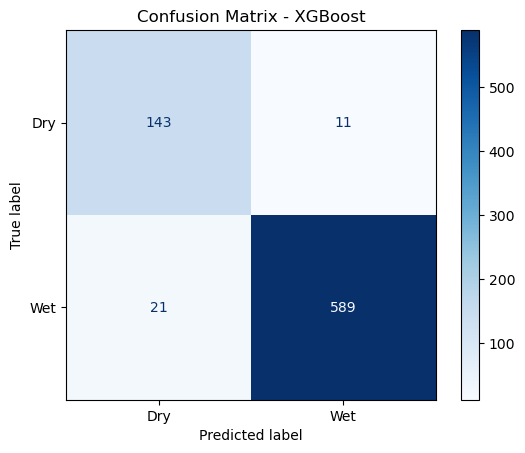

In [14]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [15]:
# Make feature importances table
feature_cols = X_train.columns.tolist()

coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": XGB_model.feature_importances_
})

#Sort by absolute value to see most important features
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print(coefficients[['Feature', 'Coefficient']].to_string(index=False))


           Feature  Coefficient
     wetdry_status     0.816903
        Out-degree     0.040024
       elev_min_cm     0.036470
     aspect_ne_pct     0.010387
                vp     0.008559
      slp_mean_pct     0.008066
             rhmax     0.007656
             rhmin     0.007633
     aspect_se_pct     0.007348
          LengthKM     0.005559
                ws     0.005455
       elev_max_cm     0.005371
              tmax     0.004989
         TotDASqKm     0.004887
           etgrass     0.004763
               sph     0.004734
     aspect_nw_pct     0.004295
          AreaSqKm     0.004036
              srad     0.004016
              tmin     0.003537
         etalfalfa     0.002807
        ArbolateSu     0.002505
         In-degree     0.000000
             Slope     0.000000
MaxDepth_Threshold     0.000000
       MaxDepth_cm     0.000000
    elev_median_cm     0.000000
            ToNode     0.000000
          FromNode     0.000000
         curv_mean     0.000000
       c

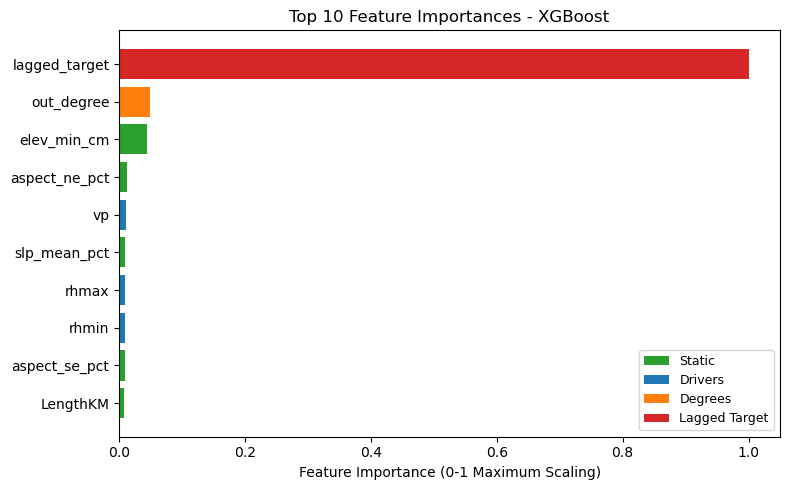

In [16]:
# Rename features for visualization
importance = coefficients[['Feature', 'Abs_Coefficient']].copy()
importance['Feature'] = importance['Feature'].replace({
    'Out-degree': 'out_degree',
    'In-degree': 'in_degree',
    'wetdry_status': 'lagged_target',
})

# Scale to 0-1 (max-normalization, consistent with LR notebook)
importance['Importance'] = importance['Abs_Coefficient'] / importance['Abs_Coefficient'].max()

# Color-code feature importances by category (consistent across notebooks)
from matplotlib.patches import Patch

FEATURE_CATEGORIES = {
    'lagged_target': 'Lagged Target',
    'in_degree': 'Degrees',
    'out_degree': 'Degrees',
}
for v in ['tmax', 'tmin', 'srad', 'prcp', 'vp', 'ws',
          'etgrass', 'etalfalfa', 'rhmax', 'rhmin', 'sph']:
    FEATURE_CATEGORIES[v] = 'Drivers'
for v in ['ArbolateSu', 'AreaSqKm', 'TotDASqKm', 'Slope', 'LengthKM',
          'FromNode', 'ToNode',
          'aspect_ne_pct', 'aspect_nw_pct', 'aspect_se_pct', 'aspect_sw_pct',
          'curv_mean', 'curv_median',
          'elev_max_cm', 'elev_mean_cm', 'elev_median_cm', 'elev_min_cm',
          'slp_mean_pct', 'slp_median_pct']:
    FEATURE_CATEGORIES[v] = 'Static'
for v in ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']:
    FEATURE_CATEGORIES[v] = 'Other Obs'

CATEGORY_COLORS = {
    'Lagged Target': '#d62728',  # red
    'Drivers':       '#1f77b4',  # blue
    'Static':        '#2ca02c',  # green
    'Degrees':       '#ff7f0e',  # orange
    'Other Obs':     '#9467bd',  # purple
    'Other':         '#7f7f7f',  # gray
}

def feature_color(name):
    return CATEGORY_COLORS[FEATURE_CATEGORIES.get(name, 'Other')]

def add_category_legend(ax, features):
    seen = []
    for f in features:
        cat = FEATURE_CATEGORIES.get(f, 'Other')
        if cat not in seen:
            seen.append(cat)
    handles = [Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in seen]
    ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=True)

# Plot top 10
top10 = importance.head(10)
features_top = top10['Feature'][::-1].tolist()
values_top   = top10['Importance'][::-1].tolist()
bar_colors   = [feature_color(f) for f in features_top]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features_top, values_top, color=bar_colors)
ax.set_xlabel('Feature Importance (0-1 Maximum Scaling)')
ax.set_title('Top 10 Feature Importances - XGBoost')
add_category_legend(ax, features_top)
plt.tight_layout()
plt.show()

## Comparison Across Split Strategies

In [17]:
# Train and evaluate XGBoost with each split strategy
# Stream order columns excluded from features — saved separately for post-hoc evaluation
drop_cols = ['NHDPlusID', 'SiteIDCode', 'Date',
             'StreamOrde', 'FCode', 'n_discharge', 'n_water_presence', 'has_data']
splits = {
    'Random': random_split(central_df),
    'Temporal': temporal_split(central_df),
    'Site-Based': site_split(central_df),
}

split_data = {}
split_orders = {}
results = []

for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    orders_te = X_te['StreamOrde'].values  # save before dropping

    X_tr = X_tr.drop(drop_cols, axis=1, errors='ignore')
    X_te = X_te.drop(drop_cols, axis=1, errors='ignore')

    # ADASYN
    adasyn = ADASYN(random_state=42)
    X_tr_res, y_tr_res = adasyn.fit_resample(X_tr, y_tr)

    # Train
    model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    model.fit(X_tr_res, y_tr_res)

    # Predict
    y_pred = model.predict(X_te)

    split_data[name] = (y_te, y_pred)
    split_orders[name] = orders_te
    results.append({
        'Split': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
    })

# Display metrics table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

     Split  Accuracy  ROC-AUC       F1
    Random  0.986692 0.977818 0.992054
  Temporal  0.958115 0.947073 0.973554
Site-Based  0.905336 0.911371 0.923717


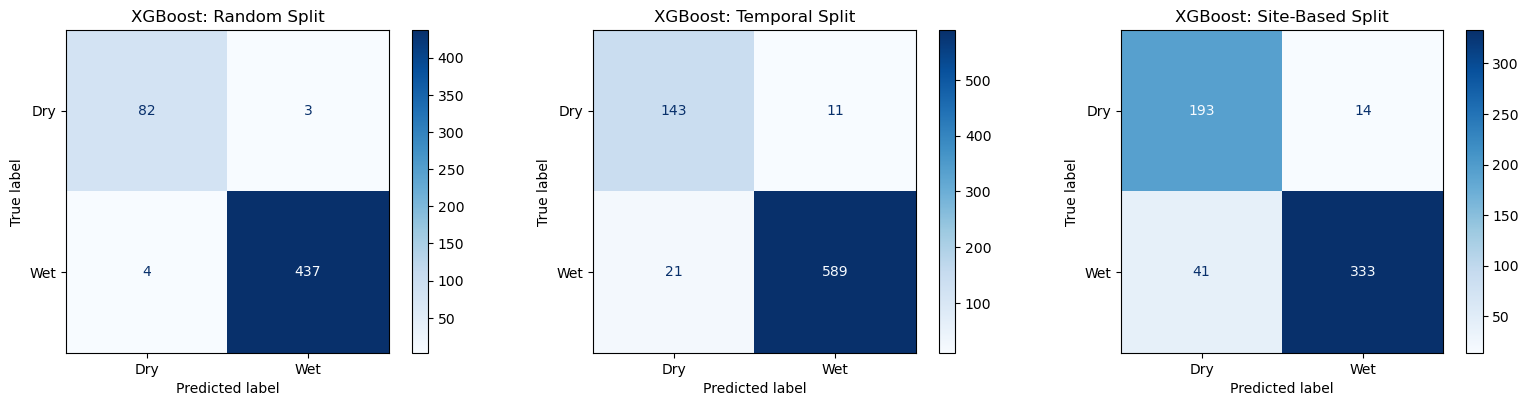


Random Split
              precision    recall  f1-score   support

         Dry      0.953     0.965     0.959        85
         Wet      0.993     0.991     0.992       441

    accuracy                          0.987       526
   macro avg      0.973     0.978     0.976       526
weighted avg      0.987     0.987     0.987       526


Temporal Split
              precision    recall  f1-score   support

         Dry      0.872     0.929     0.899       154
         Wet      0.982     0.966     0.974       610

    accuracy                          0.958       764
   macro avg      0.927     0.947     0.936       764
weighted avg      0.960     0.958     0.959       764


Site-Based Split
              precision    recall  f1-score   support

         Dry      0.825     0.932     0.875       207
         Wet      0.960     0.890     0.924       374

    accuracy                          0.905       581
   macro avg      0.892     0.911     0.900       581
weighted avg      0.912   

In [18]:
# Confusion matrices and classification reports
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (y_te, y_p)) in zip(axes, split_data.items()):
    cm = confusion_matrix(y_te, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f'XGBoost: {name} Split')

plt.tight_layout()
plt.show()

for name, (y_te, y_p) in split_data.items():
    print(f"\n{'='*50}")
    print(f"{name} Split")
    print('='*50)
    print(classification_report(y_te, y_p, target_names=['Dry', 'Wet'], digits=3))

## Stream Order Comparison

In [19]:
order_values = [1, 2, 3]

for split_name, (y_te, y_pred) in split_data.items():
    orders = split_orders[split_name]
    print(f"\n{'='*55}")
    print(f"Stream Order Breakdown — {split_name} Split")
    print('='*55)

    rows = []
    for order in order_values:
        mask = orders == order
        if mask.sum() == 0:
            continue
        yt = np.array(y_te)[mask]
        yp = y_pred[mask]
        rows.append({
            'Order': order,
            'N': int(mask.sum()),
            'Accuracy': accuracy_score(yt, yp),
            'ROC-AUC': roc_auc_score(yt, yp) if len(np.unique(yt)) > 1 else float('nan'),
            'F1': f1_score(yt, yp),
        })

    order_df = pd.DataFrame(rows)
    print(order_df.to_string(index=False))


Stream Order Breakdown — Random Split
 Order   N  Accuracy  ROC-AUC       F1
     1 262  0.980916 0.969895 0.988558
     2 164  0.993902 0.976190 0.996516
     3 100  0.990000 0.993671 0.993631

Stream Order Breakdown — Temporal Split
 Order   N  Accuracy  ROC-AUC       F1
     1 392  0.951531 0.939370 0.966957
     2 235  0.957447 0.944962 0.975490
     3 137  0.978102 0.986957 0.986784

Stream Order Breakdown — Site-Based Split
 Order   N  Accuracy  ROC-AUC       F1
     1 343  0.868805 0.889753 0.900662
     2 120  0.916667 0.885694 0.687500
     3 118  1.000000      NaN 1.000000


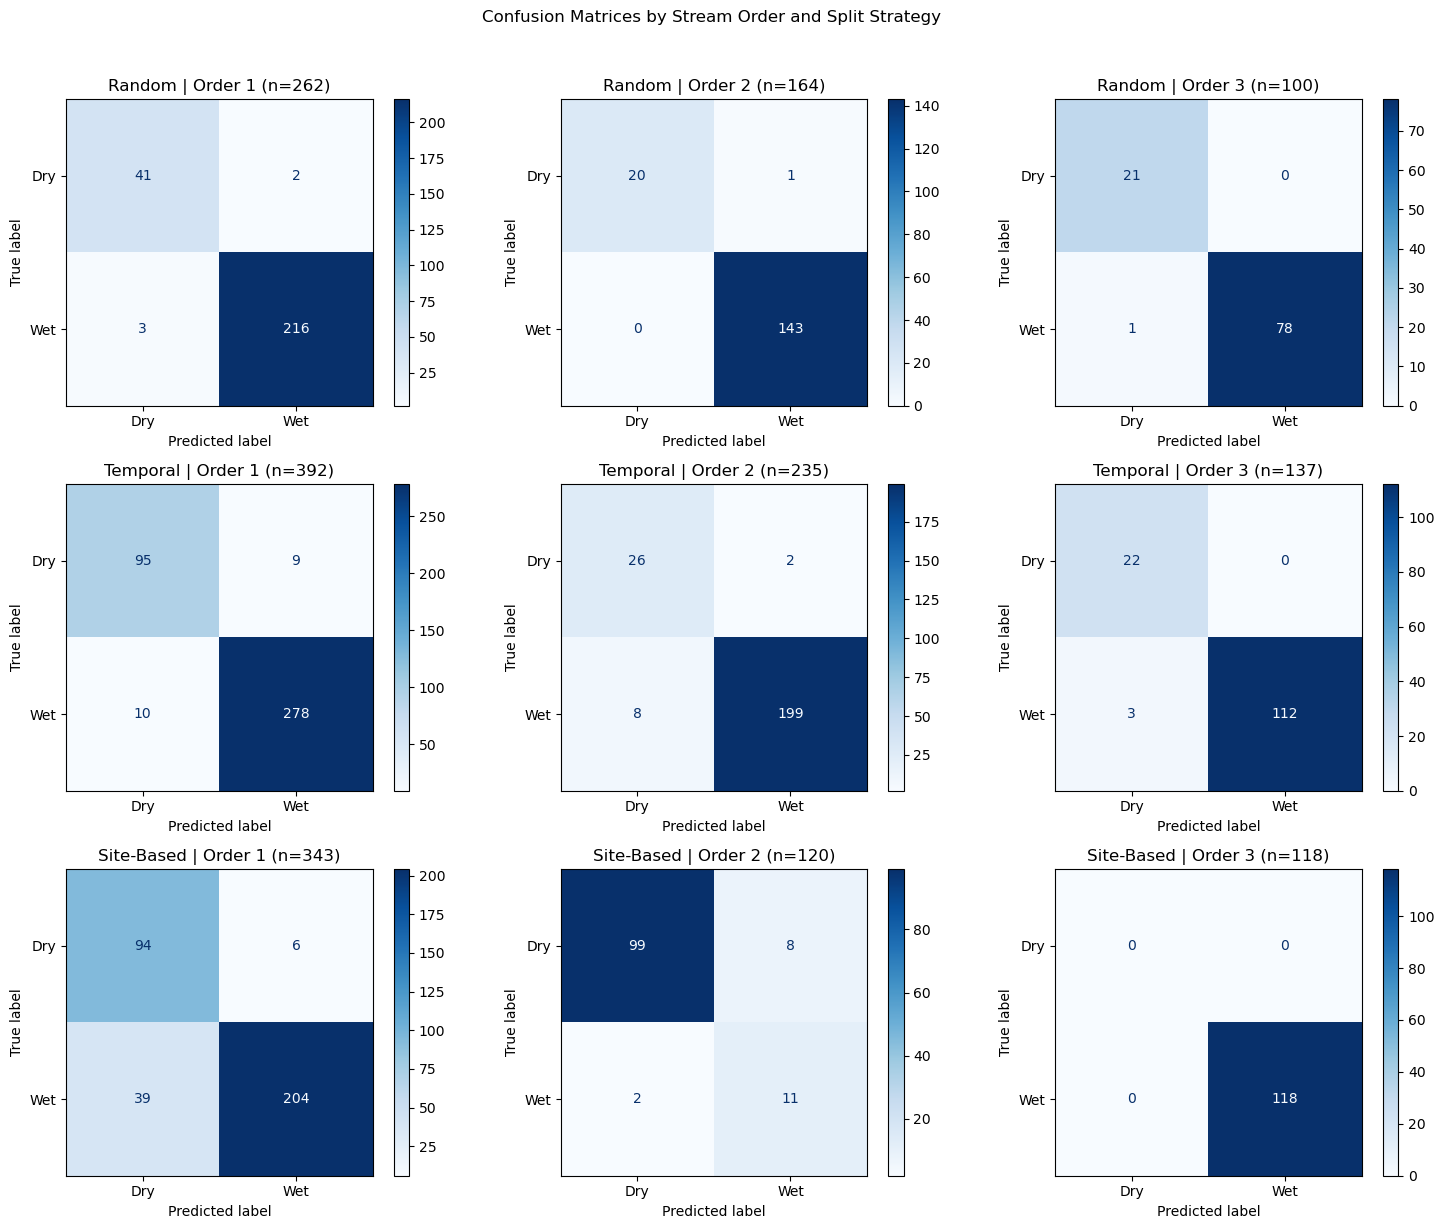

In [20]:
order_values = [1, 2, 3]
n_splits = len(split_data)
n_orders = len(order_values)

fig, axes = plt.subplots(n_splits, n_orders, figsize=(5 * n_orders, 4 * n_splits))

for row_idx, (split_name, (y_te, y_pred)) in enumerate(split_data.items()):
    orders = split_orders[split_name]
    for col_idx, order in enumerate(order_values):
        ax = axes[row_idx][col_idx]
        mask = orders == order
        if mask.sum() == 0:
            ax.set_visible(False)
            continue
        yt = np.array(y_te)[mask]
        yp = y_pred[mask]
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
        disp.plot(cmap='Blues', values_format='d', ax=ax)
        ax.set_title(f'{split_name} | Order {order} (n={mask.sum()})')

plt.suptitle('Confusion Matrices by Stream Order and Split Strategy', y=1.02)
plt.tight_layout()
plt.show()

## Inference

In [21]:
def predict_site_date(model, central_df, site_id, date, days_ahead=3):
  """
  Predict wet/dry status for a given site on day n+days_ahead given its wet/dry status and features on day n.
  
  Parameters:
  -----------
  model : XGBoostClassifier
      Trained XGBoost model
  central_df : pd.DataFrame
      Complete dataset with all features
  site_id : str
      Site identifier (e.g., "HoboSite100")
  date : str
      Date in format "YYYY-MM-DD"
  
  Returns:
  --------
  str : Prediction result with probability
  """
  date = pd.to_datetime(date)
  site_id = str(site_id)

  row = central_df[(central_df["SiteIDCode"] == site_id) & (central_df["Date"] == date)]

  if row.empty:
      return f"No data found for Site {site_id} on {date.date()}"
  
  Xq = row[feature_cols]

  pred_class = model.predict(Xq)
  pred_prob = model.predict_proba(Xq)[:, 1]

  return f"Site {site_id} on {(date + pd.Timedelta(days=days_ahead)).date()} (predicted from {date.date()}): {'DRY' if pred_class == 0 else 'WET'}, (P(wet)={pred_prob[0]:.4f})"

In [22]:
# Example inference
predict_site_date(
    model=XGB_model,
    central_df=central_df,
    site_id="HoboSite100",
    date="2020-10-22"
)

'Site HoboSite100 on 2020-10-25 (predicted from 2020-10-22): DRY, (P(wet)=0.0018)'